In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
df_path = "./transcribed_refined.csv"
header = ['filename', 'txt', 'model_transcript', 'cer']

df = pd.read_csv(df_path, header=None, names=header, delimiter='|')

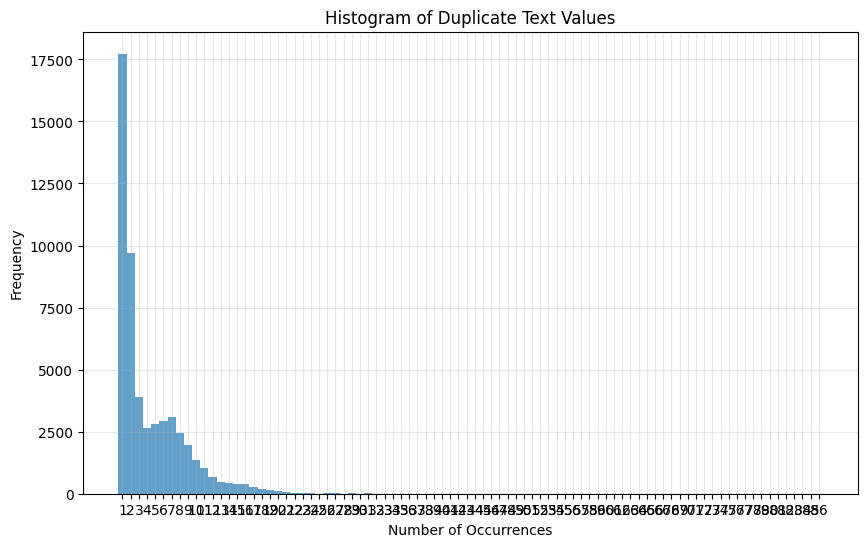

Total unique text values: 52861
Number of text values that appear more than once: 35132
Maximum occurrences of any text value: 86

Most frequent text values:
txt
เป็นต้น                                                                  86
ช่วงเวลาเดินทางนี้เว้นช่วงปีใหม่มั้ยอะครับสำหรับต่างประเทศอ่ะครับ        41
มิลเนอร์จัดไป                                                            41
ย้อนหลังภาพเบื้องหลังเครดิตจากไอจีหลายคนนะคะ                             38
ชอบหลายความเห็นในกระทู้นี้ความคิดเห็นที่อ่านแล้วอารมณ์ดีจัง              38
วันนั้นบอกโย่งอามแชร์คุณหลอกดาวสรุปผมเป็นเกรียนสยามดีที่สุดครับคุณส้ม    37
ดีใจครับตื่นมามีข่าวดีประเดิมโพสต์แรกในบอร์ดใหม่                         37
กร๊ากพี่เอ๋ก็                                                            35
เอป้าเมย์เคยบอกว่าถ้าถูกรางวัลจะแบ่งให้เค้าครึ่งนึงชิมิอิอิอิ            35
สงสารคุณต้นจังเลยเซ็งพิม                                                 34
Name: count, dtype: int64


In [9]:
# Count occurrences of each text value
txt_counts = df['txt'].value_counts()

# Create histogram of the counts
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(txt_counts.values, bins=range(1, max(txt_counts.values) + 2), align='left', alpha=0.7)
plt.xlabel('Number of Occurrences')
plt.ylabel('Frequency')
plt.title('Histogram of Duplicate Text Values')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, max(txt_counts.values) + 1))
plt.show()

# Print some statistics about duplicates
duplicate_counts = txt_counts[txt_counts > 1]
print(f"Total unique text values: {len(txt_counts)}")
print(f"Number of text values that appear more than once: {len(duplicate_counts)}")
if len(duplicate_counts) > 0:
    print(f"Maximum occurrences of any text value: {max(duplicate_counts)}")
    print("\nMost frequent text values:")
    print(txt_counts.head(10))

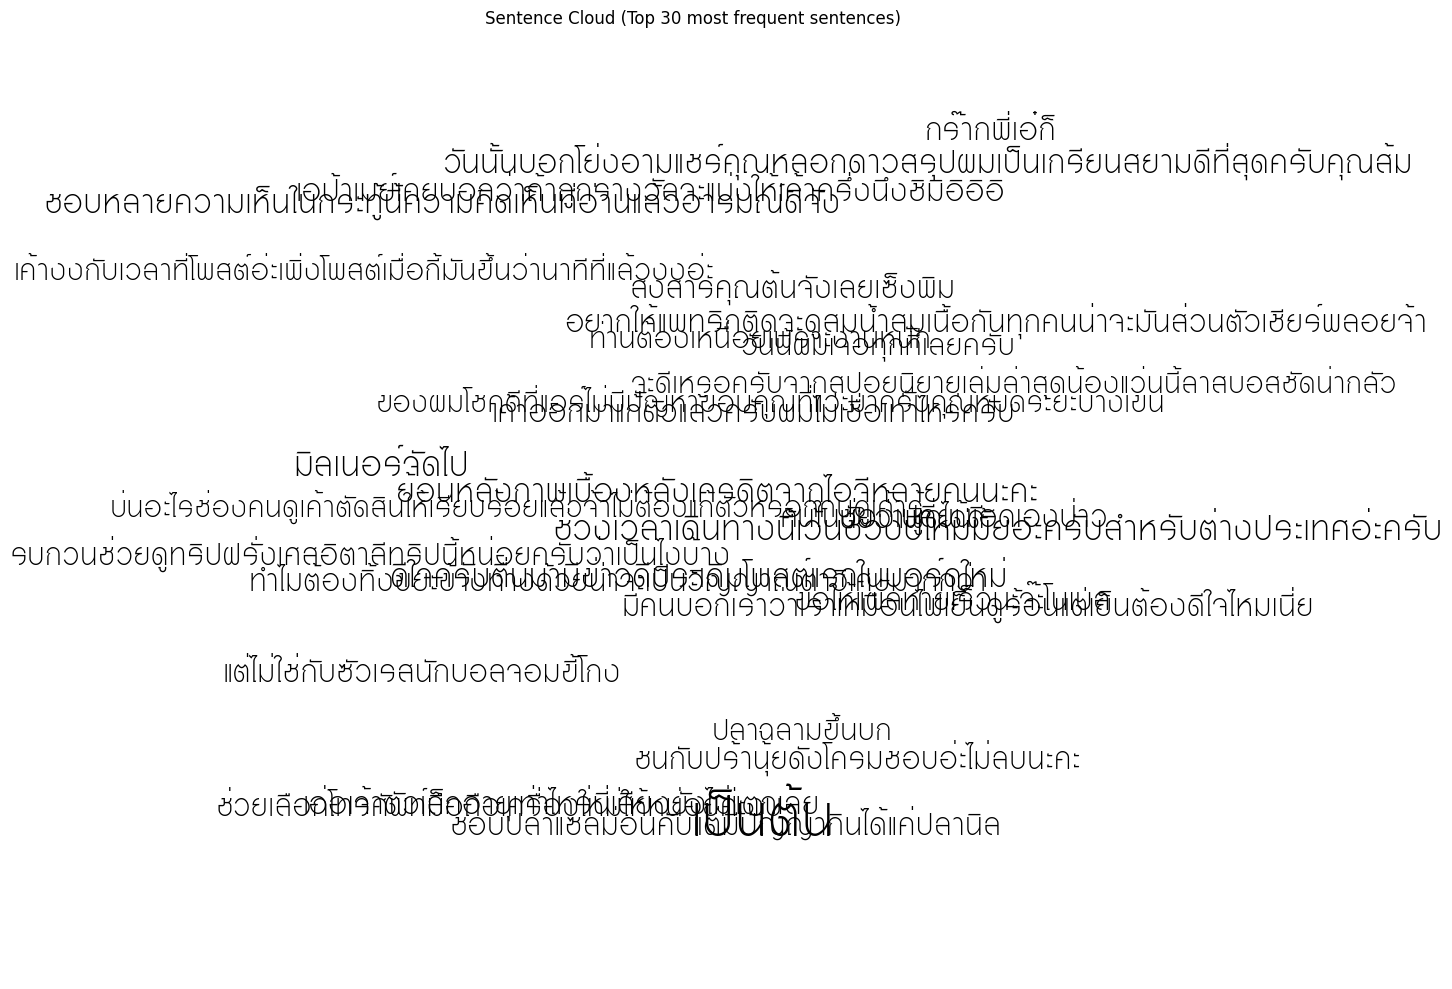

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from matplotlib.font_manager import FontProperties

thai_font = FontProperties(family='Sawasdee')

# Get frequency of each sentence
sentence_counts = df['txt'].value_counts()

# Take top N sentences (adjust as needed)
top_sentences = sentence_counts.head(30)

# Create a scatter plot with text size proportional to frequency
plt.figure(figsize=(14, 10))
plt.axis('off')

for i, (sentence, count) in enumerate(top_sentences.items()):
    # Random position for each sentence
    x = random.uniform(0.1, 0.9)
    y = random.uniform(0.1, 0.9)
    
    # Size proportional to frequency
    size = 10 + (count / max(top_sentences)) * 30
    
    # Add text with size based on frequency
    plt.text(x, y, sentence, fontsize=size, 
             ha='center', va='center', wrap=True, fontproperties=thai_font)

plt.title("Sentence Cloud (Top 30 most frequent sentences)")
plt.tight_layout()
plt.show()